<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/Abbate_et_al.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carga del Modelo entrenado

In [7]:
!wget https://zenodo.org/records/15565400/files/EfficientNetV2S%20Trained%20Model%20Weights.zip

--2025-06-13 13:21:27--  https://zenodo.org/records/15565400/files/EfficientNetV2S%20Trained%20Model%20Weights.zip
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.43.25, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 227385399 (217M) [application/octet-stream]
Saving to: ‘EfficientNetV2S Trained Model Weights.zip’

EfficientNetV2S Tra 100%[===================>] 216.85M  3.21MB/s    in 58s     

2025-06-13 13:22:26 (3.74 MB/s) - ‘EfficientNetV2S Trained Model Weights.zip’ saved [227385399/227385399]



In [8]:
!unzip "/content/EfficientNetV2S Trained Model Weights.zip"

Archive:  /content/EfficientNetV2S Trained Model Weights.zip
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/assets/
 extracting: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/fingerprint.pb  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/keras_metadata.pb  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/saved_model.pb  
   creating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/variables.data-00000-of-00001  
  inflating: effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/variables/variables.index  


In [9]:
!wget https://zenodo.org/records/15565400/files/Replication%20Data.zip

--2025-06-13 13:22:29--  https://zenodo.org/records/15565400/files/Replication%20Data.zip
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.48.194, 188.185.43.25, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 852640867 (813M) [application/octet-stream]
Saving to: ‘Replication Data.zip’

Replication Data.zi 100%[===================>] 813.14M  20.3MB/s    in 49s     

2025-06-13 13:23:19 (16.6 MB/s) - ‘Replication Data.zip’ saved [852640867/852640867]



In [10]:
!unzip "/content/Replication Data.zip"

Archive:  /content/Replication Data.zip
   creating: Replication Data/
  inflating: Replication Data/ARG_2010_EPHC-S2_v03_M_v06_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2013_EPHC-S2_v03_M_v06_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2018_EPHC-S2_v01_M_v05_A_SEDLAC-03_all.dta  
  inflating: Replication Data/ARG_2022_EPHC-S2_v01_M_v01_A_SEDLAC-03_all.dta  
  inflating: Replication Data/censo2010_fullraw_p.dta  
  inflating: Replication Data/deciles_2010.xlsx  
 extracting: Replication Data/income_estimates_2013.cpg  
  inflating: Replication Data/income_estimates_2013.dbf  
  inflating: Replication Data/income_estimates_2013.prj  
  inflating: Replication Data/income_estimates_2013.shp  
  inflating: Replication Data/income_estimates_2013.shx  
 extracting: Replication Data/income_estimates_2018.cpg  
  inflating: Replication Data/income_estimates_2018.dbf  
  inflating: Replication Data/income_estimates_2018.prj  
  inflating: Replication Data/income_estima

In [11]:
from keras.layers import TFSMLayer

# Ruta al directorio que contiene el modelo, no al archivo `.pb`
model_path = '/content/effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141/'

# Cargar el modelo como capa inferencial
layer = TFSMLayer(model_path, call_endpoint='serving_default')

# Nueva imagen con Sentinel-2

In [ ]:
!pip install earthengine-api --quiet

import ee
ee.Authenticate()
ee.Initialize(project='sanguine-healer-331000')

In [ ]:
import ee

# Punto de interés
point = ee.Geometry.Point([-58.45, -34.6])

# Parche de 300 m x 300 m
aoi_300m = point.buffer(1500).bounds()

# Selección de imagen Sentinel-2 con baja nubosidad
s2 = (ee.ImageCollection('COPERNICUS/S2_SR')
      .filterBounds(point)
      .filterDate('2022-01-01', '2022-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))
      .sort('CLOUDY_PIXEL_PERCENTAGE')
      .first())

# Selección de bandas RGB
rgb_image = s2.select(['B4', 'B3', 'B2']).toFloat()

# Exportar imagen a Google Drive
task = ee.batch.Export.image.toDrive(
    image=rgb_image,
    description='patch_300m_sentinel2_rgb',
    folder='earthengine',
    fileNamePrefix='patch_300m_sentinel2_rgb',
    region=aoi_300m,
    scale=10,  # 10 m/píxel
    crs='EPSG:4326',
    maxPixels=1e8
)

task.start()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install rasterio

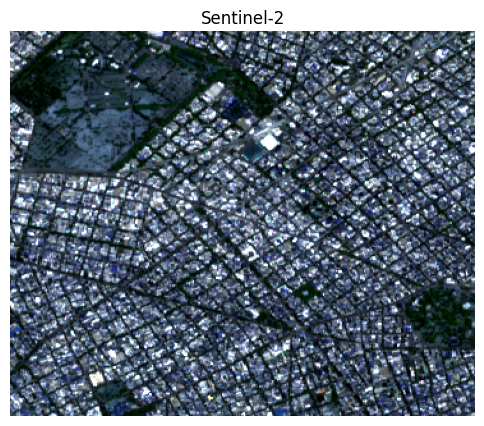

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

img_path = '/content/drive/MyDrive/earthengine/patch_300m_sentinel2_rgb.tif'

with rasterio.open(img_path) as src:
    img = src.read()

# Seleccionar bandas RGB (Bandas 4-3-2 → índices 3,2,1)
r = img[3 - 1].astype(np.float32)
g = img[2 - 1].astype(np.float32)
b = img[1 - 1].astype(np.float32)

# Apilar en eje de color
rgb = np.stack([r, g, b], axis=-1)

# Normalización usando percentiles
p2, p98 = np.percentile(rgb, (2, 98))
rgb_norm = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# Mostrar
plt.figure(figsize=(6,6))
plt.imshow(rgb_norm)
plt.axis('off')
plt.title('Sentinel-2')
plt.show()

# Nueva imagen scrapeada

In [1]:
from google.colab import userdata
import json

!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = {
    'username': userdata.get('KAGGLE_USER'),
    'key': userdata.get('KAGGLE_KEY')}
with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json


import kagglehub
path = kagglehub.dataset_download("leonardocaravaggio/ge-images5")

100%|██████████| 895M/895M [00:20<00:00, 46.9MB/s]

Extracting files...


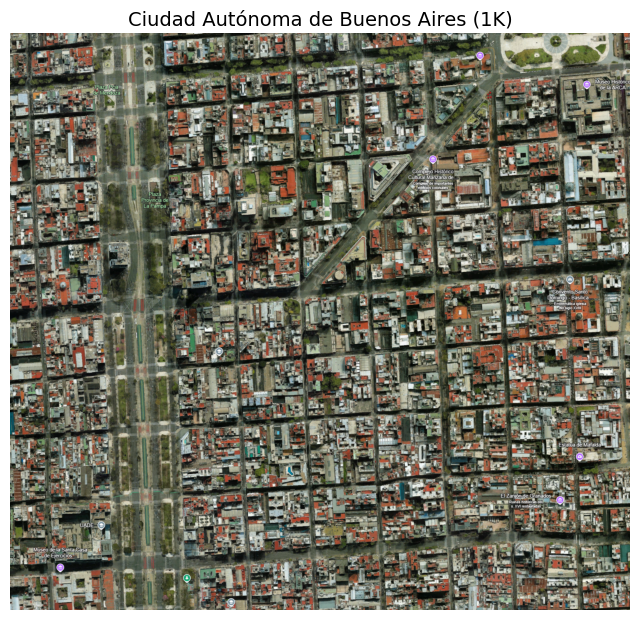

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Simulación de nombre de archivo (asegurate que `ciudades.Nombre_Aglomerado[i]` esté definido)
nombre_aglomerado = "Ciudad Autónoma de Buenos Aires"
nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")
ruta_completa = os.path.join(path, nombre_archivo)
img_1km = ruta_completa + " - 1K.png"

# Cargar imagen
img = mpimg.imread(img_1km)

# Mostrar imagen
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title(nombre_aglomerado + ' (1K)', fontsize=14)
plt.show()

In [3]:
import matplotlib.image as mpimg

# Cargar imagen
img = mpimg.imread(img_1km)

# Obtener dimensiones
alto, ancho = img.shape[:2]
pixeles_totales = alto * ancho

# Definir ancho real en metros (1 km)
ancho_metros = 1_000  # 1 km

# Calcular resolución espacial (m/píxel)
resolucion_m_por_pixel = ancho_metros / ancho

# Mostrar resultados
print(f"Dimensiones: {ancho} x {alto} píxeles")
print(f"Total de píxeles: {pixeles_totales:,}")
print(f"Resolución espacial: {resolucion_m_por_pixel:.2f} metros por píxel")

Dimensiones: 1904 x 1773 píxeles
Total de píxeles: 3,375,792
Resolución espacial: 0.53 metros por píxel


# Inferencia

In [4]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 54.5 MB/s eta 0:00:00


## Inferencia de una imagen

In [ ]:
import numpy as np
import matplotlib.image as mpimg
from skimage.transform import resize
import tensorflow as tf

def process_image(img_path, factor, patch_size=128):
    # Cargar imagen PNG RGB
    img = mpimg.imread(img_path).astype(np.float32)

    # Eliminar canal alfa si existe
    if img.shape[-1] == 4:
        img = img[:, :, :3]

    # Remuestrear
    img_resized = resize(img, (img.shape[0] // factor, img.shape[1] // factor, 3),
                         preserve_range=True, anti_aliasing=True).astype(np.float32)

    # Seleccionar parche central
    H, W, _ = img_resized.shape
    start_y = (H - patch_size) // 2
    start_x = (W - patch_size) // 2
    patch = img_resized[start_y:start_y + patch_size, start_x:start_x + patch_size, :]

    return patch

factor = 4
patch_size = 128


nombre_aglomerado = "Gran La Plata"
nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")
ruta_completa = os.path.join(path, nombre_archivo)
img_1km = ruta_completa + " - 1K.png"
img_10km = ruta_completa + " - 10K.png"

# Procesar ambas imágenes
patch_1km = process_image(img_1km, factor, patch_size)  # shape (128,128,3)
patch_10km = process_image(img_10km, factor, patch_size)  # shape (128,128,3)

# Construir parche con 8 canales
parche_8 = np.zeros((patch_size, patch_size, 8), dtype=np.float32)

# Canales 0,1,2 = patch_1km RGB
parche_8[:, :, 0:3] = patch_1km

# Canal 3 = ceros (ya está por defecto)

# Canales 4,5,6 = patch_10km RGB
parche_8[:, :, 4:7] = patch_10km

# Canal 7 = ceros (ya está por defecto)

# Asegurar que no haya NaNs
parche_8 = np.nan_to_num(parche_8, nan=0.0)

# Inferencia
input_tensor = tf.convert_to_tensor(parche_8[np.newaxis, ...], dtype=tf.float32)  # (1,128,128,8)
raw_output = layer(input_tensor, training=False)

# Obtener predicción
if isinstance(raw_output, dict):
    preds = raw_output[list(raw_output.keys())[0]].numpy().squeeze()
else:
    preds = raw_output.numpy().squeeze()

print(f"Predicción del modelo: {preds:.4f}")

Predicción del modelo: -1.0266


## Gini ??

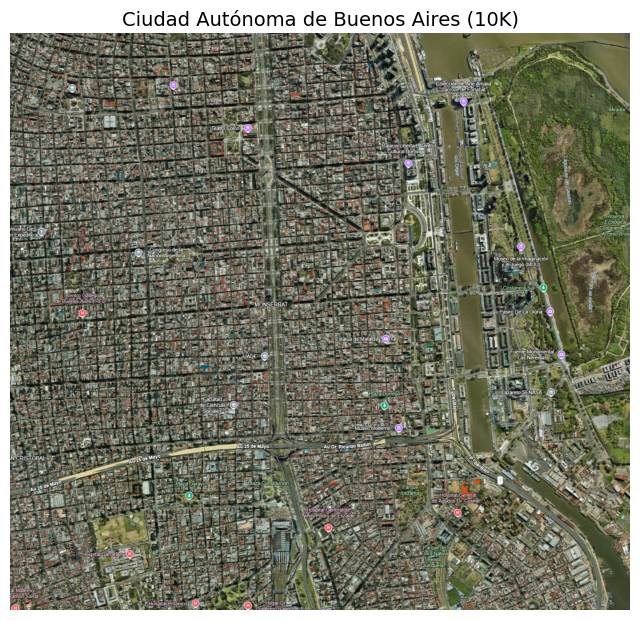

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Simulación de nombre de archivo (asegurate que `ciudades.Nombre_Aglomerado[i]` esté definido)
nombre_aglomerado = "Ciudad Autónoma de Buenos Aires"
nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")
ruta_completa = os.path.join(path, nombre_archivo)
img_10km = ruta_completa + " - 10K.png"

# Cargar imagen
img = mpimg.imread(img_10km)

# Mostrar imagen
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title(nombre_aglomerado + ' (10K)', fontsize=14)
plt.show()

Tamaño de imagen: 1773 x 1904
Predicciones obtenidas: (100,)
Gini de desigualdad urbana: 0.2128


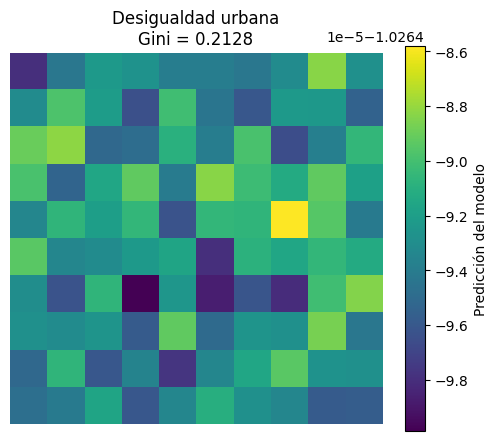

In [18]:
import numpy as np
import matplotlib.image as mpimg
import tensorflow as tf
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt

# Cargar imagen
nombre_aglomerado = "Gran La Plata"
nombre_archivo = nombre_aglomerado.replace("/", ".").replace(":", "_").replace("'", "!")
ruta_completa = os.path.join(path, nombre_archivo)
img_1km = ruta_completa + " - 1K.png"
img_10km = ruta_completa + " - 10K.png"

img = mpimg.imread(img_10km).astype(np.float32)
if img.shape[-1] == 4:
    img = img[:, :, :3]  # Eliminar canal alfa si lo tiene

H, W, _ = img.shape
print(f"Tamaño de imagen: {H} x {W}")

# Tamaño de cada parche (asumiendo 10x10 división)
n_patches = 10
patch_H = H // n_patches
patch_W = W // n_patches

# Guardamos predicciones de cada parche
preds = []

for i in range(n_patches):
    for j in range(n_patches):
        # Extraer parche
        patch = img[i * patch_H:(i + 1) * patch_H, j * patch_W:(j + 1) * patch_W, :]

        # Resize a 128x128 si es necesario
        patch_resized = tf.image.resize(patch, (128, 128)).numpy()

        # Rellenar hasta 8 canales
        patch_8 = np.pad(patch_resized, ((0, 0), (0, 0), (0, 5)), mode='constant')

        # Asegurar que no haya NaNs
        patch_8 = np.nan_to_num(patch_8)

        # Inferencia
        input_tensor = tf.convert_to_tensor(patch_8[np.newaxis, ...], dtype=tf.float32)
        raw_output = layer(input_tensor, training=False)

        # Obtener predicción
        if isinstance(raw_output, dict):
            pred = raw_output[list(raw_output.keys())[0]].numpy().squeeze()
        else:
            pred = raw_output.numpy().squeeze()

        preds.append(pred)

# Convertimos a array
preds = np.array(preds)
print(f"Predicciones obtenidas: {preds.shape}")

# Calcular índice de Gini
def gini(array):
    array = np.array(array, dtype=np.float32)
    if np.amin(array) < 0:
        array -= np.amin(array)  # Desplazar a no negativos
    array += 1e-8  # Evitar división por cero
    array = np.sort(array)
    n = array.shape[0]
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))


gini_value = gini(preds)
print(f"Gini de desigualdad urbana: {gini_value:.4f}")

# Visualización tipo heatmap
preds_grid = preds.reshape((n_patches, n_patches))

plt.figure(figsize=(6, 5))
plt.imshow(preds_grid, cmap='viridis')
plt.colorbar(label='Predicción del modelo')
plt.title(f'Desigualdad urbana\nGini = {gini_value:.4f}')
plt.axis('off')
plt.show()

In [13]:
import pandas as pd
ciudades=pd.read_csv("Gini_EPH.csv")

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import tensorflow as tf
from tqdm import tqdm

ciudades['Desigualdad_Abbate']=np.nan

for i in tqdm(range(len(ciudades)), desc="Procesando ciudades"):
    if pd.isna(ciudades.loc[i, "Desigualdad_Abbate"]):
        try:
            nombre_archivo = ciudades.Nombre_Aglomerado[i].replace("/", ".").replace(":", "_").replace("'", "!")
            img_15k = os.path.join(path, nombre_archivo + " - 10K.png")

            img = mpimg.imread(img_15k).astype(np.float32)
            if img.shape[-1] == 4:
                img = img[:, :, :3]

            H, W, _ = img.shape
            n_patches = 10
            patch_H = H // n_patches
            patch_W = W // n_patches

            preds = []
            for r in range(n_patches):
                for c in range(n_patches):
                    patch = img[r * patch_H:(r + 1) * patch_H, c * patch_W:(c + 1) * patch_W, :]
                    patch_resized = tf.image.resize(patch, (128, 128)).numpy()
                    patch_8 = np.pad(patch_resized, ((0, 0), (0, 0), (0, 5)), mode='constant')
                    patch_8 = np.nan_to_num(patch_8)

                    input_tensor = tf.convert_to_tensor(patch_8[np.newaxis, ...], dtype=tf.float32)
                    raw_output = layer(input_tensor, training=False)

                    if isinstance(raw_output, dict):
                        pred = raw_output[list(raw_output.keys())[0]].numpy().squeeze()
                    else:
                        pred = raw_output.numpy().squeeze()

                    preds.append(pred)

            preds = np.array(preds)
            ciudades.loc[i, "Desigualdad_Abbate"] = gini(preds)

        except Exception as e:
            print(f"Error en {ciudades.Nombre_Aglomerado[i]}: {e}")


Procesando ciudades: 100%|██████████| 32/32 [04:25<00:00,  8.30s/it]


In [24]:
ciudades.head(2)

,Unnamed: 0,AGLOMERADO,Nombre_Aglomerado,Gini_Personas,Gini_Hogares,Desigualdad_Abbate
0,0,2,Gran La Plata,0.477884,0.430569,0.212761
1,25,32,Ciudad Autónoma de Buenos Aires,0.405170,0.415689,0.245865


In [25]:
from scipy.stats import pearsonr

# Eliminar pares con NaN
x = ciudades["Desigualdad_Abbate"]
y = ciudades["Gini_Hogares"]
mask = x.notna() & y.notna()

# Calcular correlación de Pearson y p-value
r, p = pearsonr(x[mask], y[mask])

print(f"Coeficiente de Pearson: {r:.3f}")
print(f"Valor p: {p:.5f}")

Coeficiente de Pearson: -0.353
Valor p: 0.04728


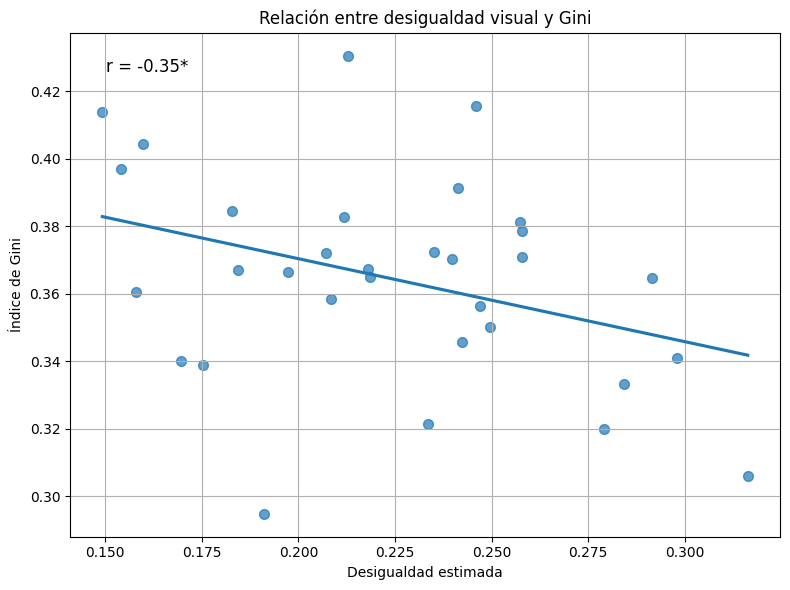

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Filtrar datos válidos
x = ciudades["Desigualdad_Abbate"]
y = ciudades["Gini_Hogares"]
mask = x.notna() & y.notna()
x_valid = x[mask]
y_valid = y[mask]

# Calcular correlación
r, p = pearsonr(x_valid, y_valid)

# Determinar nivel de significancia
if p < 0.001:
    stars = "***"
elif p < 0.01:
    stars = "**"
elif p < 0.05:
    stars = "*"
else:
    stars = ""

# Crear gráfico
plt.figure(figsize=(8, 6))
sns.regplot(x=x_valid, y=y_valid, ci=None, scatter_kws={"s": 50, "alpha": 0.7})

# Anotar r y p
plt.text(0.05, 0.95, f"r = {r:.2f}{stars}", ha="left", va="top", transform=plt.gca().transAxes, fontsize=12)

plt.xlabel("Desigualdad estimada")
plt.ylabel("Índice de Gini")
plt.title("Relación entre desigualdad visual y Gini")
plt.grid(True)
plt.tight_layout()
plt.show()